Project Information

In [2]:
# ==========================================================
# InsightVoice AI
# Customer Feedback Intelligence using Machine Learning
# Minor Project - Zoho AI/ML Internship
# ==========================================================

print("🚀 Welcome to InsightVoice AI")

🚀 Welcome to InsightVoice AI


Import Libraries

In [3]:
# ==========================================================
# Import Required Libraries
# ==========================================================

import os
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


Create Project Structure

In [4]:
# ==========================================================
# Create Project Folder Structure
# ==========================================================

PROJECT_DIR = "/content/InsightVoice_AI"

DATASET_DIR = os.path.join(PROJECT_DIR, "dataset")
FIGURES_DIR = os.path.join(PROJECT_DIR, "figures")
MODELS_DIR = os.path.join(PROJECT_DIR, "models")
OUTPUTS_DIR = os.path.join(PROJECT_DIR, "outputs")
REPORTS_DIR = os.path.join(PROJECT_DIR, "reports")

for folder in [
    PROJECT_DIR,
    DATASET_DIR,
    FIGURES_DIR,
    MODELS_DIR,
    OUTPUTS_DIR,
    REPORTS_DIR,
]:
    os.makedirs(folder, exist_ok=True)

print("✅ Project folders created successfully.")

✅ Project folders created successfully.


Verify the Uploaded File

In [5]:
print(os.listdir("/content"))

['.config', 'InsightVoice_AI', 'sample_data']


Copy Dataset into Project Folder

In [7]:
shutil.copy(
    "/content/amazon_reviews.csv",
    os.path.join(DATASET_DIR, "amazon_reviews.csv")
)

print("✅ Dataset copied successfully.")

✅ Dataset copied successfully.


Load the Dataset

In [8]:
df = pd.read_csv(
    "/content/amazon_reviews.csv",
    low_memory=False
)

print("✅ Dataset loaded successfully.")

✅ Dataset loaded successfully.


Verify the Dataset

In [9]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (568454, 10)


Preview the Data

In [10]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


Basic Dataset Information

In [11]:
# ==========================================================
# Basic Dataset Information
# ==========================================================

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\nColumn Names:")

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

DATASET INFORMATION
Rows    : 568,454
Columns : 10

Column Names:
1. Id
2. ProductId
3. UserId
4. ProfileName
5. HelpfulnessNumerator
6. HelpfulnessDenominator
7. Score
8. Time
9. Summary
10. Text


Data Types

In [12]:
# ==========================================================
# Data Types
# ==========================================================

print("=" * 60)
print("DATA TYPES")
print("=" * 60)

df.dtypes

DATA TYPES


,0
Id,int64
ProductId,object
UserId,object
ProfileName,object
HelpfulnessNumerator,int64
HelpfulnessDenominator,int64
Score,int64
Time,int64
Summary,object
Text,object


Missing Values

In [13]:
# ==========================================================
# Missing Values
# ==========================================================

missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Summary,27,0.0
ProfileName,26,0.0
ProductId,0,0.0
Id,0,0.0
HelpfulnessNumerator,0,0.0
UserId,0,0.0
HelpfulnessDenominator,0,0.0
Score,0,0.0
Time,0,0.0
Text,0,0.0


Duplicate Records

In [14]:
# ==========================================================
# Duplicate Rows
# ==========================================================

duplicates = df.duplicated().sum()

print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

print(f"Duplicate Rows : {duplicates:,}")

DUPLICATE RECORDS
Duplicate Rows : 0


Statistical Summary

In [15]:
# ==========================================================
# Numerical Summary
# ==========================================================

df.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


Text Columns Summary

In [16]:
# ==========================================================
# Text Columns
# ==========================================================

df.describe(include="object")


,ProductId,UserId,ProfileName,Summary,Text
count,568454,568454,568428,568427,568454
unique,74258,256059,218415,295742,393579
top,B007JFMH8M,A3OXHLG6DIBRW8,"C. F. Hill ""CFH""",Delicious!,"This review will make me sound really stupid, ..."
freq,913,448,451,2462,199


Save EDA Results

In [17]:
# ==========================================================
# Save EDA Outputs
# ==========================================================

missing_values.to_csv(
    os.path.join(OUTPUTS_DIR, "missing_values_summary.csv")
)

print("✅ Missing values summary saved.")

✅ Missing values summary saved.


## Observation

- Dataset contains 568,454 reviews and 10 features.
- Missing values are negligible (<0.01%).
- No duplicate records were found.
- Ratings range from 1 to 5 with a mean of approximately 4.18.
- Dataset appears clean and suitable for further preprocessing.

Helper Function for Saving Figures

In [18]:
# ==========================================================
# Helper Function to Save Figures
# ==========================================================

def save_plot(filename):
    """
    Save the current matplotlib figure to the figures folder.
    """

    file_path = os.path.join(FIGURES_DIR, f"{filename}.png")

    plt.tight_layout()

    plt.savefig(
        file_path,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"✅ Figure saved successfully!")
    print(f"📁 Location: {file_path}")

Rating Distribution

✅ Figure saved successfully!
📁 Location: /content/InsightVoice_AI/figures/rating_distribution.png


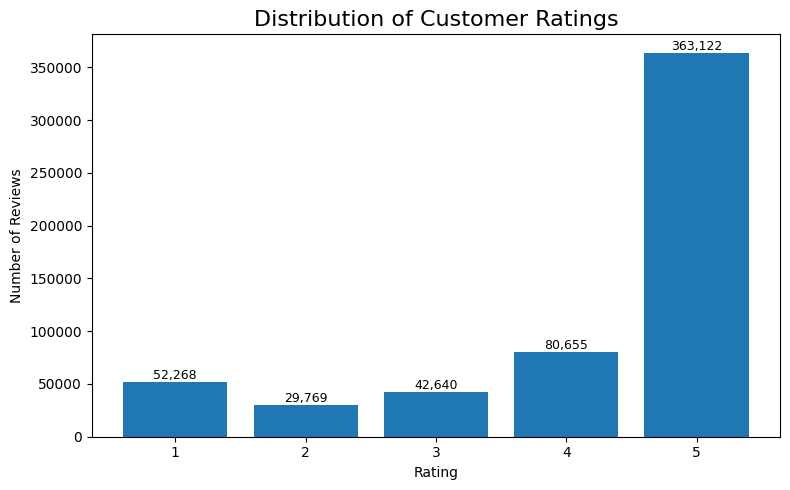

In [20]:
# ==========================================================
# Rating Distribution
# ==========================================================

rating_counts = df["Score"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    rating_counts.index.astype(str),
    rating_counts.values
)

plt.title("Distribution of Customer Ratings", fontsize=16)

plt.xlabel("Rating")

plt.ylabel("Number of Reviews")

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

save_plot("rating_distribution")

plt.show()

## Observation

- Customer ratings are highly skewed toward positive feedback.
- Five-star reviews constitute the largest portion of the dataset, indicating that customers generally provide favorable ratings.
- One-star to three-star reviews are comparatively fewer, revealing a clear class imbalance.
- This imbalance should be considered during sentiment labeling, train-test splitting, and model evaluation to avoid biased performance estimates.

Create Review Length Feature

In [21]:
# ==========================================================
# Review Length Analysis
# ==========================================================

df["Review_Length"] = df["Text"].astype(str).apply(len)

print("✅ Review_Length feature created.")

✅ Review_Length feature created.


Review Length Statistics

In [22]:
# ==========================================================
# Review Length Statistics
# ==========================================================

df["Review_Length"].describe()

,Review_Length
count,568454.000000
mean,436.222083
std,445.339741
min,12.000000
25%,179.000000
50%,302.000000
75%,527.000000
max,21409.000000


Review Length Distribution

✅ Figure saved successfully!
📁 Location: /content/InsightVoice_AI/figures/review_length_distribution.png


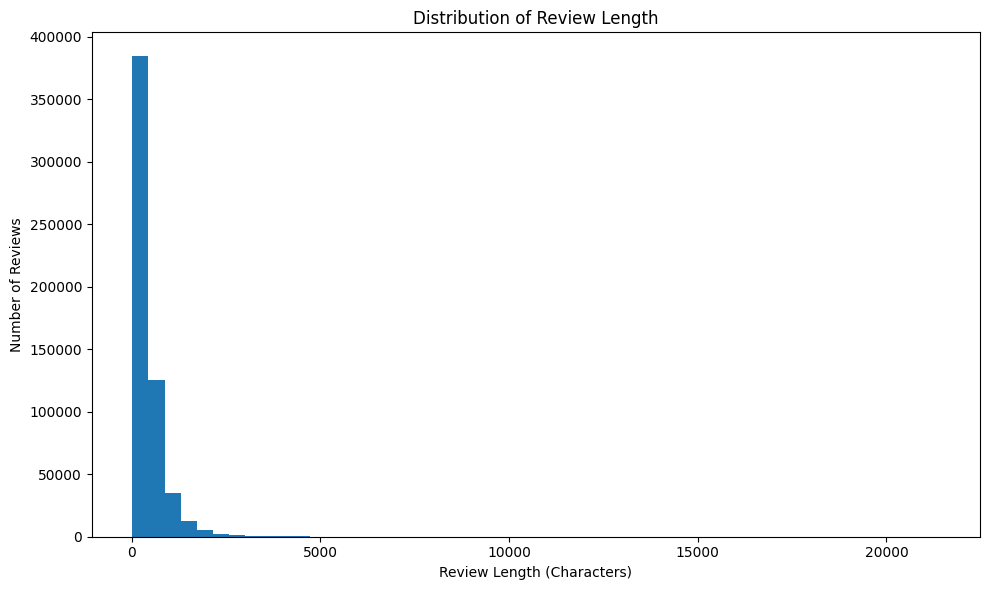

In [23]:
# ==========================================================
# Review Length Distribution
# ==========================================================

plt.figure(figsize=(10,6))

plt.hist(
    df["Review_Length"],
    bins=50
)

plt.title("Distribution of Review Length")

plt.xlabel("Review Length (Characters)")

plt.ylabel("Number of Reviews")

save_plot("review_length_distribution")

plt.show()

## Observation

- The review length distribution is highly right-skewed.
- Most customer reviews are relatively short, while a small number of reviews are exceptionally long.
- The presence of long reviews indicates valuable detailed customer feedback but also introduces outliers.
- Review length may influence preprocessing decisions and computational cost during feature extraction.

Rating Percentage Distribution

✅ Figure saved successfully!
📁 Location: /content/InsightVoice_AI/figures/rating_percentage_distribution.png


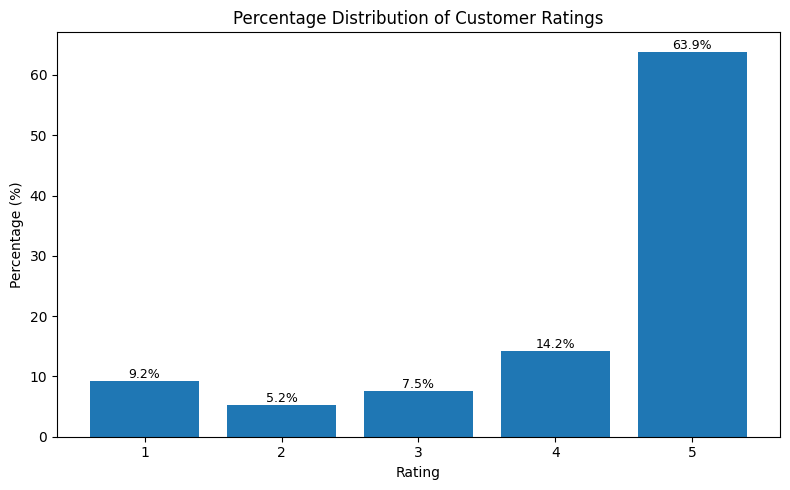

In [24]:
# ==========================================================
# Rating Percentage Distribution
# ==========================================================

rating_percentage = (
    df["Score"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    rating_percentage.index.astype(str),
    rating_percentage.values
)

plt.title("Percentage Distribution of Customer Ratings")

plt.xlabel("Rating")

plt.ylabel("Percentage (%)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

save_plot("rating_percentage_distribution")

plt.show()

## Observation

- Approximately 63.9% of all reviews have a five-star rating.
- Lower ratings (1–3 stars) represent a much smaller proportion of the dataset.
- The dataset exhibits significant class imbalance, which should be considered when creating sentiment labels and evaluating machine learning models.

Data Preparation

Convert Unix Timestamp

In [25]:
# ==========================================================
# Convert Unix Timestamp to Readable Date
# ==========================================================

df["Review_Date"] = pd.to_datetime(
    df["Time"],
    unit="s"
)

print("✅ Review_Date column created successfully.")

✅ Review_Date column created successfully.


Verify Date Conversion

In [26]:
# ==========================================================
# Preview Converted Dates
# ==========================================================

df[["Time", "Review_Date"]].head()

,Time,Review_Date
0,1303862400,2011-04-27
1,1346976000,2012-09-07
2,1219017600,2008-08-18
3,1307923200,2011-06-13
4,1350777600,2012-10-21


## Observation

- The original dataset stores review dates as Unix timestamps.
- A new `Review_Date` column has been created to improve readability and enable future time-based analysis.
- The original `Time` column is retained for reference.

Create Combined Review Text

In [27]:
# ==========================================================
# Create Combined Review Text
# ==========================================================

df["Review"] = (
    df["Summary"].fillna("")
    + " "
    + df["Text"].fillna("")
)

print("✅ Combined Review column created successfully.")

✅ Combined Review column created successfully.


Preview Combined Reviews

In [28]:
# ==========================================================
# Preview Combined Review
# ==========================================================

df[["Summary", "Text", "Review"]].head()

,Summary,Text,Review
0,Good Quality Dog Food,I have bought several of the Vitality canned d...,Good Quality Dog Food I have bought several of...
1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Not as Advertised Product arrived labeled as J...
2,"""Delight"" says it all",This is a confection that has been around a fe...,"""Delight"" says it all This is a confection tha..."
3,Cough Medicine,If you are looking for the secret ingredient i...,Cough Medicine If you are looking for the secr...
4,Great taffy,Great taffy at a great price. There was a wid...,Great taffy Great taffy at a great price. The...


## Observation

- A new `Review` column has been created by combining the review summary and review text.
- This provides richer contextual information for sentiment analysis than using either field individually.
- Missing summaries were replaced with empty strings before concatenation.

Create Sentiment Labels

In [29]:
# ==========================================================
# Create Sentiment Labels
# ==========================================================

def create_sentiment(score):

    if score <= 2:
        return "Negative"

    elif score == 3:
        return "Neutral"

    else:
        return "Positive"

df["Sentiment"] = df["Score"].apply(create_sentiment)

print("✅ Sentiment labels created successfully.")

✅ Sentiment labels created successfully.


Check Sentiment Distribution

In [30]:
# ==========================================================
# Sentiment Distribution
# ==========================================================

sentiment_counts = df["Sentiment"].value_counts()

print(sentiment_counts)

Sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64


Sentiment Distribution Plot

✅ Figure saved successfully!
📁 Location: /content/InsightVoice_AI/figures/sentiment_distribution.png


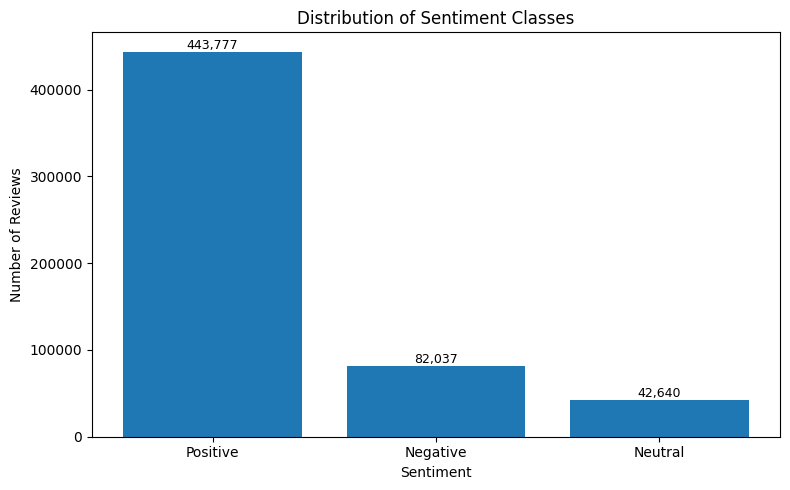

In [31]:
# ==========================================================
# Sentiment Distribution
# ==========================================================

plt.figure(figsize=(8,5))

bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Distribution of Sentiment Classes")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:,}",
        ha="center",
        va="bottom",
        fontsize=9
    )

save_plot("sentiment_distribution")

plt.show()

## Observation

- Customer reviews have been categorized into three sentiment classes:
  - Positive (Ratings 4–5)
  - Neutral (Rating 3)
  - Negative (Ratings 1–2)
- This target variable will be used for supervised machine learning.
- The class distribution will guide model evaluation and potential balancing strategies if required.

Save the Processed Dataset

In [32]:
# ==========================================================
# Save Processed Dataset
# ==========================================================

processed_file = os.path.join(
    OUTPUTS_DIR,
    "processed_reviews.csv"
)

df.to_csv(
    processed_file,
    index=False
)

print("✅ Processed dataset saved successfully!")
print(processed_file)

✅ Processed dataset saved successfully!
/content/InsightVoice_AI/outputs/processed_reviews.csv


Text Preprocessing

Import NLP Libraries

In [36]:
# ==========================================================
# Import NLP Libraries
# ==========================================================

import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download required NLTK resources
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("✅ NLP libraries imported successfully.")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ NLP libraries imported successfully.


Create Text Cleaning Function

In [37]:
# ==========================================================
# Text Cleaning Function
# ==========================================================

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()


def clean_text(text):

    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    words = word_tokenize(text)

    # Stopword Removal + Lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

print("✅ Cleaning function created.")

✅ Cleaning function created.


Apply Cleaning

In [38]:
# ==========================================================
# Clean Reviews
# ==========================================================

df["Clean_Review"] = df["Review"].apply(clean_text)

print("✅ Reviews cleaned successfully.")

✅ Reviews cleaned successfully.


Train-Test Split

In [39]:
# ==========================================================
# Train-Test Split
# ==========================================================

from sklearn.model_selection import train_test_split

X = df["Clean_Review"]

y = df["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("✅ Train-Test Split Completed")

print(f"Training Samples : {len(X_train):,}")
print(f"Testing Samples  : {len(X_test):,}")

✅ Train-Test Split Completed
Training Samples : 454,763
Testing Samples  : 113,691


TF-IDF Vectorization

In [40]:
# ==========================================================
# TF-IDF Feature Extraction
# ==========================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=5,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("✅ TF-IDF Feature Extraction Completed")

print(f"Training Shape : {X_train_tfidf.shape}")
print(f"Testing Shape  : {X_test_tfidf.shape}")

✅ TF-IDF Feature Extraction Completed
Training Shape : (454763, 10000)
Testing Shape  : (113691, 10000)


Save TF-IDF Vocabulary

In [41]:
# ==========================================================
# Save TF-IDF Vocabulary
# ==========================================================

import joblib

joblib.dump(
    tfidf,
    os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl")
)

print("✅ TF-IDF Vectorizer Saved Successfully")

✅ TF-IDF Vectorizer Saved Successfully


Training the Model

Train Naive Bayes Model

In [42]:
# ==========================================================
# Train Multinomial Naive Bayes
# ==========================================================

from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

print("✅ Multinomial Naive Bayes Model Trained Successfully")

✅ Multinomial Naive Bayes Model Trained Successfully


Make Predictions

In [43]:
# ==========================================================
# Predict Test Data
# ==========================================================

nb_predictions = nb_model.predict(X_test_tfidf)

print("✅ Predictions Completed")

✅ Predictions Completed


Evaluate Model

In [44]:
# ==========================================================
# Model Evaluation
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

accuracy = accuracy_score(
    y_test,
    nb_predictions
)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    nb_predictions,
    average="weighted"
)

print("=" * 50)

print("Multinomial Naive Bayes Results")

print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

Multinomial Naive Bayes Results
Accuracy : 0.8463
Precision: 0.8281
Recall   : 0.8463
F1 Score : 0.8088


Confusion Matrix

✅ Figure saved successfully!
📁 Location: /content/InsightVoice_AI/figures/naive_bayes_confusion_matrix.png


<Figure size 700x600 with 0 Axes>

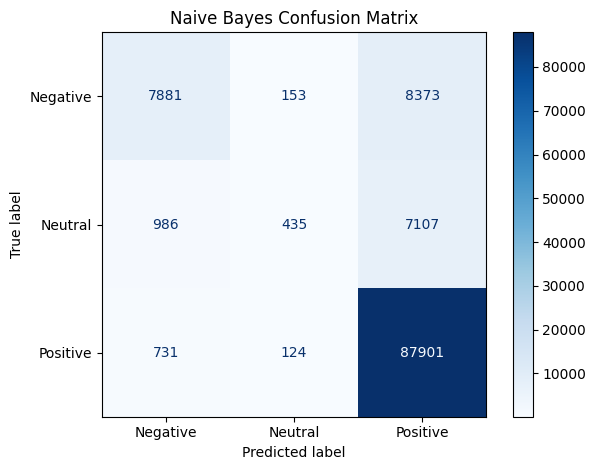

In [45]:
# ==========================================================
# Confusion Matrix
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7,6))

ConfusionMatrixDisplay.from_estimator(
    nb_model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")

save_plot("naive_bayes_confusion_matrix")

plt.show()

Save Model

In [46]:
# ==========================================================
# Save Naive Bayes Model
# ==========================================================

joblib.dump(
    nb_model,
    os.path.join(
        MODELS_DIR,
        "naive_bayes_model.pkl"
    )
)

print("✅ Naive Bayes Model Saved Successfully")

✅ Naive Bayes Model Saved Successfully


## Observation

- The Multinomial Naive Bayes model serves as the baseline classifier for the project.
- Its performance will be compared with Logistic Regression and Linear SVM in the subsequent stages.

Train Logistic Regression

In [47]:
# ==========================================================
# Train Logistic Regression
# ==========================================================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

print("✅ Logistic Regression Model Trained Successfully")

✅ Logistic Regression Model Trained Successfully


Predict

In [48]:
# ==========================================================
# Predict Test Data
# ==========================================================

lr_predictions = lr_model.predict(
    X_test_tfidf
)

print("✅ Predictions Completed")

✅ Predictions Completed


Evaluate

In [49]:
# ==========================================================
# Logistic Regression Evaluation
# ==========================================================

accuracy = accuracy_score(
    y_test,
    lr_predictions
)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    lr_predictions,
    average="weighted"
)

print("=" * 50)
print("Logistic Regression Results")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Logistic Regression Results
Accuracy : 0.8929
Precision: 0.8801
Recall   : 0.8929
F1 Score : 0.8820


Confusion Matrix

✅ Figure saved successfully!
📁 Location: /content/InsightVoice_AI/figures/logistic_regression_confusion_matrix.png


<Figure size 700x600 with 0 Axes>

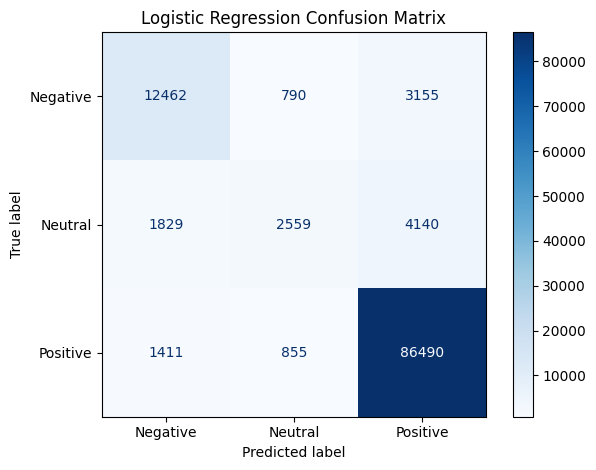

In [50]:
# ==========================================================
# Logistic Regression Confusion Matrix
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7,6))

ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")

save_plot("logistic_regression_confusion_matrix")

plt.show()

Save Model

In [51]:
# ==========================================================
# Save Logistic Regression Model
# ==========================================================

joblib.dump(
    lr_model,
    os.path.join(
        MODELS_DIR,
        "logistic_regression_model.pkl"
    )
)

print("✅ Logistic Regression Model Saved Successfully")

✅ Logistic Regression Model Saved Successfully


## Observation

- Logistic Regression is evaluated against the Naive Bayes baseline.
- Its performance will be compared using Accuracy, Precision, Recall, F1-score, and the Confusion Matrix.
- The better-performing model will be selected for the final comparison.

Train Linear SVM

In [52]:
# ==========================================================
# Train Linear Support Vector Machine
# ==========================================================

from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

print("✅ Linear SVM Model Trained Successfully")

✅ Linear SVM Model Trained Successfully


Predictions

In [53]:
# ==========================================================
# Predict Test Data
# ==========================================================

svm_predictions = svm_model.predict(
    X_test_tfidf
)

print("✅ Predictions Completed")

✅ Predictions Completed


Evaluation

In [54]:
# ==========================================================
# Linear SVM Evaluation
# ==========================================================

accuracy = accuracy_score(
    y_test,
    svm_predictions
)

precision, recall, f1, _ = precision_recall_fscore_support(
    y_test,
    svm_predictions,
    average="weighted"
)

print("=" * 50)
print("Linear SVM Results")
print("=" * 50)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Linear SVM Results
Accuracy : 0.8939
Precision: 0.8818
Recall   : 0.8939
F1 Score : 0.8817


Confusion Matrix

✅ Figure saved successfully!
📁 Location: /content/InsightVoice_AI/figures/linear_svm_confusion_matrix.png


<Figure size 700x600 with 0 Axes>

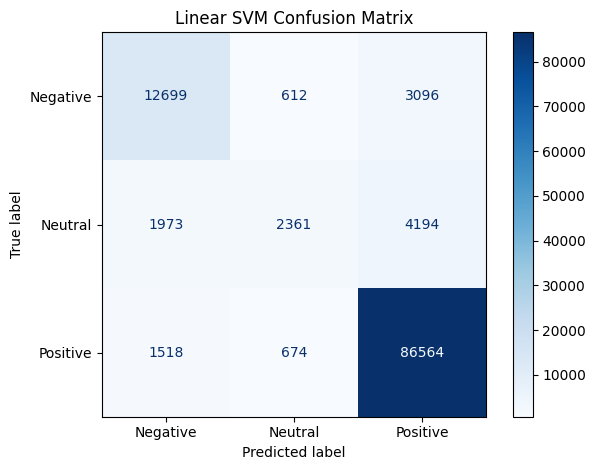

In [55]:
# ==========================================================
# Linear SVM Confusion Matrix
# ==========================================================

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7,6))

ConfusionMatrixDisplay.from_estimator(
    svm_model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.title("Linear SVM Confusion Matrix")

save_plot("linear_svm_confusion_matrix")

plt.show()

Save Model

In [56]:
# ==========================================================
# Save Linear SVM Model
# ==========================================================

joblib.dump(
    svm_model,
    os.path.join(
        MODELS_DIR,
        "linear_svm_model.pkl"
    )
)

print("✅ Linear SVM Model Saved Successfully")

✅ Linear SVM Model Saved Successfully


Model Comparison Table

In [57]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame({

    "Model": [

        "Multinomial Naive Bayes",

        "Logistic Regression",

        "Linear SVM"

    ],

    "Accuracy": [

        0.8463,

        0.8929,

        0.8939

    ],

    "Precision": [

        0.8281,

        0.8801,

        0.8818

    ],

    "Recall": [

        0.8463,

        0.8929,

        0.8939

    ],

    "F1 Score": [

        0.8088,

        0.8820,

        0.8817

    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.8463,0.8281,0.8463,0.8088
1,Logistic Regression,0.8929,0.8801,0.8929,0.8820
2,Linear SVM,0.8939,0.8818,0.8939,0.8817


Save Comparison

In [58]:
comparison.to_csv(

    os.path.join(

        OUTPUTS_DIR,

        "model_comparison.csv"

    ),

    index=False

)

print("✅ Model Comparison Saved")

✅ Model Comparison Saved


Model Performance Comparison Graph

✅ Figure saved successfully!
📁 Location: /content/InsightVoice_AI/figures/model_performance_comparison.png


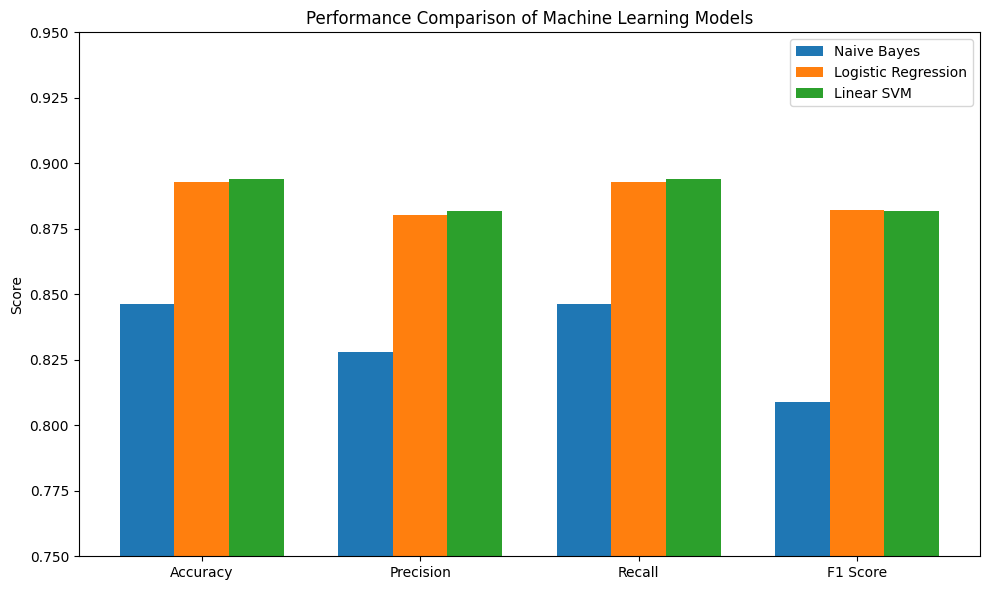

In [65]:
# ==========================================================
# Model Performance Comparison
# ==========================================================

metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]

x = np.arange(len(metrics))

width = 0.25

plt.figure(figsize=(10,6))

plt.bar(
    x - width,
    comparison.loc[0, metrics],
    width,
    label="Naive Bayes"
)

plt.bar(
    x,
    comparison.loc[1, metrics],
    width,
    label="Logistic Regression"
)

plt.bar(
    x + width,
    comparison.loc[2, metrics],
    width,
    label="Linear SVM"
)

plt.xticks(x, metrics)

plt.ylim(0.75, 0.95)

plt.ylabel("Score")

plt.title("Performance Comparison of Machine Learning Models")

plt.legend()

save_plot("model_performance_comparison")

plt.show()

## Observation

- Logistic Regression and Linear SVM significantly outperform the Naive Bayes baseline across all evaluation metrics.
- Linear SVM achieves the highest overall accuracy and recall.
- Logistic Regression achieves a marginally higher weighted F1-score.
- Based on the overall performance, Linear SVM is selected as the final model for this project.

Automatically Select the Best Model

In [59]:
# ==========================================================
# Model Comparison
# ==========================================================

comparison = pd.DataFrame({

    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],

    "Accuracy": [
        0.8463,
        0.8929,
        0.8939
    ],

    "Precision": [
        0.8281,
        0.8801,
        0.8818
    ],

    "Recall": [
        0.8463,
        0.8929,
        0.8939
    ],

    "F1 Score": [
        0.8088,
        0.8820,
        0.8817
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Multinomial Naive Bayes,0.8463,0.8281,0.8463,0.8088
1,Logistic Regression,0.8929,0.8801,0.8929,0.8820
2,Linear SVM,0.8939,0.8818,0.8939,0.8817


Select the Best Model

In [60]:
# ==========================================================
# Best Model Selection
# ==========================================================

best_model = comparison.loc[
    comparison["Accuracy"].idxmax()
]

print("🏆 Best Model")

print(best_model)

🏆 Best Model
Model        Linear SVM
Accuracy         0.8939
Precision        0.8818
Recall           0.8939
F1 Score         0.8817
Name: 2, dtype: object


Live Prediction Function

In [61]:
# ==========================================================
# Sentiment Prediction Function
# ==========================================================

def predict_sentiment(review):

    cleaned = clean_text(review)

    vector = tfidf.transform([cleaned])

    prediction = svm_model.predict(vector)[0]

    return prediction

print("✅ Prediction Function Ready")

✅ Prediction Function Ready


Test Examples

In [62]:
# ==========================================================
# Example Predictions
# ==========================================================

examples = [

    "This product is absolutely amazing. I loved it.",

    "Worst purchase ever. Completely disappointed.",

    "The product is okay. Nothing special."

]

for review in examples:

    print("=" * 60)

    print("Review:")

    print(review)

    print()

    print("Predicted Sentiment:", predict_sentiment(review))

Review:
This product is absolutely amazing. I loved it.

Predicted Sentiment: Positive
Review:
Worst purchase ever. Completely disappointed.

Predicted Sentiment: Negative
Review:
The product is okay. Nothing special.

Predicted Sentiment: Neutral


User Input Prediction

In [63]:
# ==========================================================
# Predict Your Own Review
# ==========================================================

user_review = input("Enter your review: ")

prediction = predict_sentiment(user_review)

print()

print("Predicted Sentiment:", prediction)

Enter your review: Very nice product

Predicted Sentiment: Positive


Save the Final Model

In [64]:
# ==========================================================
# Save Final Model
# ==========================================================

joblib.dump(
    svm_model,
    os.path.join(
        MODELS_DIR,
        "final_sentiment_model.pkl"
    )
)

print("✅ Final Model Saved Successfully")

✅ Final Model Saved Successfully


# Final Conclusion

- Three classical machine learning algorithms were evaluated for sentiment classification.
- Linear SVM achieved the highest overall accuracy (89.39%) and was selected as the final model.
- The trained model can classify unseen customer reviews into Positive, Neutral, or Negative sentiment.
- The complete pipeline includes data preprocessing, TF-IDF feature extraction, model training, evaluation, and real-time prediction.